# Tutorial 2 — Probability tools for automated inspection

## 1. Problem / context

An automated vision system flags possible solder defects on circuit boards. Historically, 2% of boards are defective. The system flags 95% of defective boards, but it also flags 8% of good boards.

We will use this one engineering case to practise the Session 2 workflow: events, a four-cell table, independence versus mutual exclusivity, total probability, and Bayes' theorem. Brooks Chapter 2 has the full probability rules; here the aim is to keep the denominators attached to engineering questions.

Let $D$ mean that a board is defective and $F$ mean that it is flagged. The model inputs are

$$
P(D)=0.02,\qquad P(F\mid D)=0.95,\qquad P(F\mid D^c)=0.08.
$$

These are **model probabilities**, not counts from a new production sample.

## 2. Events, complements, and two paths to a flag

A suitable sample space records both the physical condition and the system decision:

$$
S=\{D\cap F,\ D\cap F^c,\ D^c\cap F,\ D^c\cap F^c\}.
$$

The four cells are mutually exclusive and exhaustive. The multiplication rule fills each cell; the addition rule combines mutually exclusive paths. In particular $P(D\cup F)=P(D)+P(F)-P(D\cap F)$, because boards that are both defective and flagged would otherwise be counted twice.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p_defect = 0.02
sensitivity = 0.95
false_positive_rate = 0.08

p_defect_and_flag = p_defect * sensitivity
p_good_and_flag = (1 - p_defect) * false_positive_rate
p_flag = p_defect_and_flag + p_good_and_flag
p_not_flag = 1 - p_flag
p_defect_or_flag = p_defect + p_flag - p_defect_and_flag

pd.Series(
    {
        "P(D and F)": p_defect_and_flag,
        "P(F)": p_flag,
        "P(not F)": p_not_flag,
        "P(D or F)": p_defect_or_flag,
    }
)


P(D and F)    0.0190
P(F)          0.0974
P(not F)      0.9026
P(D or F)     0.0984
dtype: float64

Pause: why is $P(D\cup F)$ not $P(D)+P(F)$? Which boards would otherwise be counted twice?

## 3. Natural frequencies and a contingency table

Probabilities are often easier as expected counts. For a hypothetical batch of 10,000 boards the model gives 200 defective and 9,800 good boards. These are **expected counts under the model**, not newly observed data.


In [2]:
n = 10_000
n_defective = round(n * p_defect)
n_good = n - n_defective

true_positive = round(n_defective * sensitivity)
false_negative = n_defective - true_positive
false_positive = round(n_good * false_positive_rate)
true_negative = n_good - false_positive

table = pd.DataFrame(
    {
        "flagged": [true_positive, false_positive],
        "not_flagged": [false_negative, true_negative],
    },
    index=["defective", "good"],
)
table["total"] = table.sum(axis=1)
table.loc["total"] = table.sum(axis=0)
table


,flagged,not_flagged,total
defective,190,10,200
good,784,9016,9800
total,974,9026,10000


A conditional probability restricts the denominator to the stated reference group.


In [3]:
sensitivity_from_table = (
    table.loc["defective", "flagged"] / table.loc["defective", "total"]
)
false_positive_rate_from_table = (
    table.loc["good", "flagged"] / table.loc["good", "total"]
)
positive_predictive_value = (
    table.loc["defective", "flagged"] / table.loc["total", "flagged"]
)

pd.Series(
    {
        "P(F | D), sensitivity": sensitivity_from_table,
        "P(F | not D), false-positive rate": false_positive_rate_from_table,
        "P(D | F), positive predictive value": positive_predictive_value,
    }
)


P(F | D), sensitivity                  0.950000
P(F | not D), false-positive rate      0.080000
P(D | F), positive predictive value    0.195072
dtype: float64

The same numerator, 190, appears in both $P(F\mid D)$ and $P(D\mid F)$. Sensitivity asks “of the defective boards, how many are flagged?” (denominator 200). Positive predictive value asks “of the flagged boards, how many are defective?” (denominator 974).

## 4. Independence is not mutual exclusivity

Independence would mean $P(F\mid D)=P(F)$, or equivalently $P(D\cap F)=P(D)P(F)$. Mutual exclusivity would mean $P(D\cap F)=0$.


In [4]:
independence_check = pd.Series(
    {
        "P(F | D)": sensitivity,
        "P(F)": p_flag,
        "P(D and F)": p_defect_and_flag,
        "P(D)P(F)": p_defect * p_flag,
    }
)
independence_check


P(F | D)      0.950000
P(F)          0.097400
P(D and F)    0.019000
P(D)P(F)      0.001948
dtype: float64

The events are dependent: a defective board is far more likely to be flagged than a randomly chosen board. They are not mutually exclusive either, because a board can be both defective and flagged.

## 5. Total probability and Bayes' theorem

The flagged boards arrive through two mutually exclusive paths:

$$
P(F)=P(F\mid D)P(D)+P(F\mid D^c)P(D^c)=0.95(0.02)+0.08(0.98)=0.0974.
$$

Bayes' theorem reverses the conditioning:

$$
P(D\mid F)
=\frac{P(F\mid D)P(D)}{P(F)}
=\frac{0.95(0.02)}{0.0974}
\approx 0.195.
$$


In [5]:
ppv = sensitivity * p_defect / p_flag
print(f"P(flag) = {p_flag:.4f}")
print(f"P(defect | flag) = {ppv:.4f}")


P(flag) = 0.0974
P(defect | flag) = 0.1951


Although sensitivity is 95%, a flagged board has only about a 19.5% probability of being defective. The large population of good boards produces many more false alarms than the small population of defective boards produces true alarms. **Sensitivity is not positive predictive value.**

## 6. The base-rate effect

Hold sensitivity and false-positive rate fixed, and vary only the defect base rate.


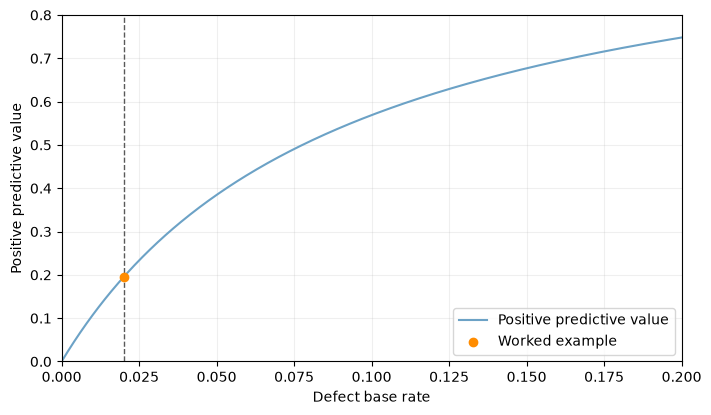

In [6]:
base_rates = np.linspace(0.0, 0.20, 401)
ppv_curve = (
    sensitivity * base_rates
    / (sensitivity * base_rates + false_positive_rate * (1 - base_rates))
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(base_rates, ppv_curve, color="#6CA2C6", label="Positive predictive value")
ax.scatter([p_defect], [ppv], color="#FF8C00", zorder=3, label="Worked example")
ax.axvline(p_defect, color="0.35", linestyle="--", linewidth=1)
ax.set_xlabel("Defect base rate")
ax.set_ylabel("Positive predictive value")
ax.set_xlim(0, 0.20)
ax.set_ylim(0, 0.80)
ax.grid(alpha=0.2)
ax.legend()
plt.show()


The detector has the same sensitivity and false-positive rate throughout the plot, yet its predictive value changes substantially. A flag must be interpreted together with the population in which the system is used.

## 7. Exact probability and simulation

Simulation checks the long-run interpretation; it does not replace the exact calculation.


In [7]:
rng = np.random.default_rng(2026)
n_sim = 100_000

defective = rng.random(n_sim) < p_defect
flagged = np.where(
    defective,
    rng.random(n_sim) < sensitivity,
    rng.random(n_sim) < false_positive_rate,
)

simulated_ppv = defective[flagged].mean()
print(f"Exact P(defect | flag) = {ppv:.4f}")
print(f"Simulated P(defect | flag) = {simulated_ppv:.4f}")
print(f"Number of simulated flags = {flagged.sum():,}")


Exact P(defect | flag) = 0.1951
Simulated P(defect | flag) = 0.1977
Number of simulated flags = 9,801


If you rerun with $n_{\mathrm{sim}}=1{,}000$, $10{,}000$, and $1{,}000{,}000$, the estimates fluctuate, but the fluctuation generally becomes smaller as the sample size grows.

## 8. Engineering improvement

Suppose the false-positive rate is reduced from 8% to 1%, while sensitivity remains 95%.


In [8]:
improved_fpr = 0.01
improved_p_flag = sensitivity * p_defect + improved_fpr * (1 - p_defect)
improved_ppv = sensitivity * p_defect / improved_p_flag

print(f"Original PPV = {ppv:.3f}")
print(f"Improved PPV = {improved_ppv:.3f}")


Original PPV = 0.195
Improved PPV = 0.660


A flag is evidence, not proof. Whether a board should be scrapped, retested, or accepted also depends on the costs of missed defects, unnecessary scrap, and confirmation.

Pause: a colleague claims “the detector is 95% accurate, so 95% of its flags are correct.” Which probability did they mix up with $P(D\mid F)$?

**Conclusion:** Tables, trees, and Bayes' theorem are three views of the same model. Name the event after the conditioning bar, use the correct reference group, and do not treat a flag as proof of a defect.
